## Initiating YOLO26 Bone Fracture Detection Training

This section outlines the setup and commencement of the training process for our YOLO26 model, focused on detecting bone fractures.

### Dataset Citation

When utilizing this dataset for your research, please cite it as follows:

*   **DOI:** 10.13140/RG.2.2.14400.34569
*   **ResearchGate:** [https://www.researchgate.net/publication/382268240_Bone_Fracture_Detection_Computer_Vision_Project](https://www.researchgate.net/publication/382268240_Bone_Fracture_Detection_Computer_Vision_Project)

### Data Export and Format

Our dataset has been exported using **Roboflow's YOLOv8 OOB (Out-of-Box)** format. While the export was done with YOLOv8, the annotation format is fully compatible with **YOLO26 OOB**, allowing for seamless integration into our YOLO26 training pipeline.

## Data Preprocessing and Augmentation with Roboflow

This section outlines the preprocessing and augmentation techniques applied to the dataset using Roboflow, which are crucial for improving model generalization and robustness.

### Preprocessing

Only one preprocessing step was applied:

*   **Resize:** All images were resized to **640x640** pixels.

### Augmentation

To increase the diversity of the training data and prevent overfitting, the following augmentation techniques were employed, resulting in **3 outputs per training example**:

*   **Crop:**
    *   Minimum Zoom: 0%
    *   Maximum Zoom: 20%
*   **Rotation:** Between -15° and +15°
*   **Saturation:** Between -25% and +25%
*   **Exposure:** Between -5% and +5%
*   **Blur:** Up to 0.5 pixels
*   **Noise:** Up to 0.1% of pixels

In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 41.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 113.9 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquer

In [2]:
from pathlib import Path

api_key = "kxvuhmB6oW38mcQS6Quj"

env_content = f"ROBOFLOW_API_KEY={api_key}\n"

Path(".env").write_text(env_content)

print(".env file created successfully!")

.env file created successfully!


In [3]:
import os
from dotenv import load_dotenv
load_dotenv()
ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")

In [4]:
from roboflow import Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("haaaaaaaaaax").project("bone-fracture-detection-daoon-ugiaj")
version = project.version(1)
dataset = version.download("yolov8-obb")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to bone-fracture-detection-1 in yolov8-obb:: 100%|██████████| 8305/8305 [00:00<00:00, 12124.10it/s]


In [5]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.5 MB/s eta 0:00:00


In [6]:
from ultralytics import YOLO
#The difference between small and medium is about 13 mAP50 but medium and x is about 7 so medium is a good choice
model = YOLO("yolo26m-obb.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [7]:
results = model.train(
    data=os.path.join(dataset.location, "data.yaml"),
    epochs=120,
    imgsz=640,
    batch=16,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    weight_decay=5e-4,
    patience=20,
    warmup_epochs=3,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,
    cache=True,
    workers=4,
    amp=True,
    distill_model="yolo26x-obb.pt" #Added by ultralytics 30 jun, 26 at 7:00 PM
)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/bone-fracture-detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=yolo26x-obb.pt, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimi

## Training Results: Curves and Accuracy

The Ultralytics framework automatically generates various plots to visualize the training process and model performance. Below, you will find the main `results.png` plot summarizing metrics like precision, recall, mAP, and loss curves over the training epochs.

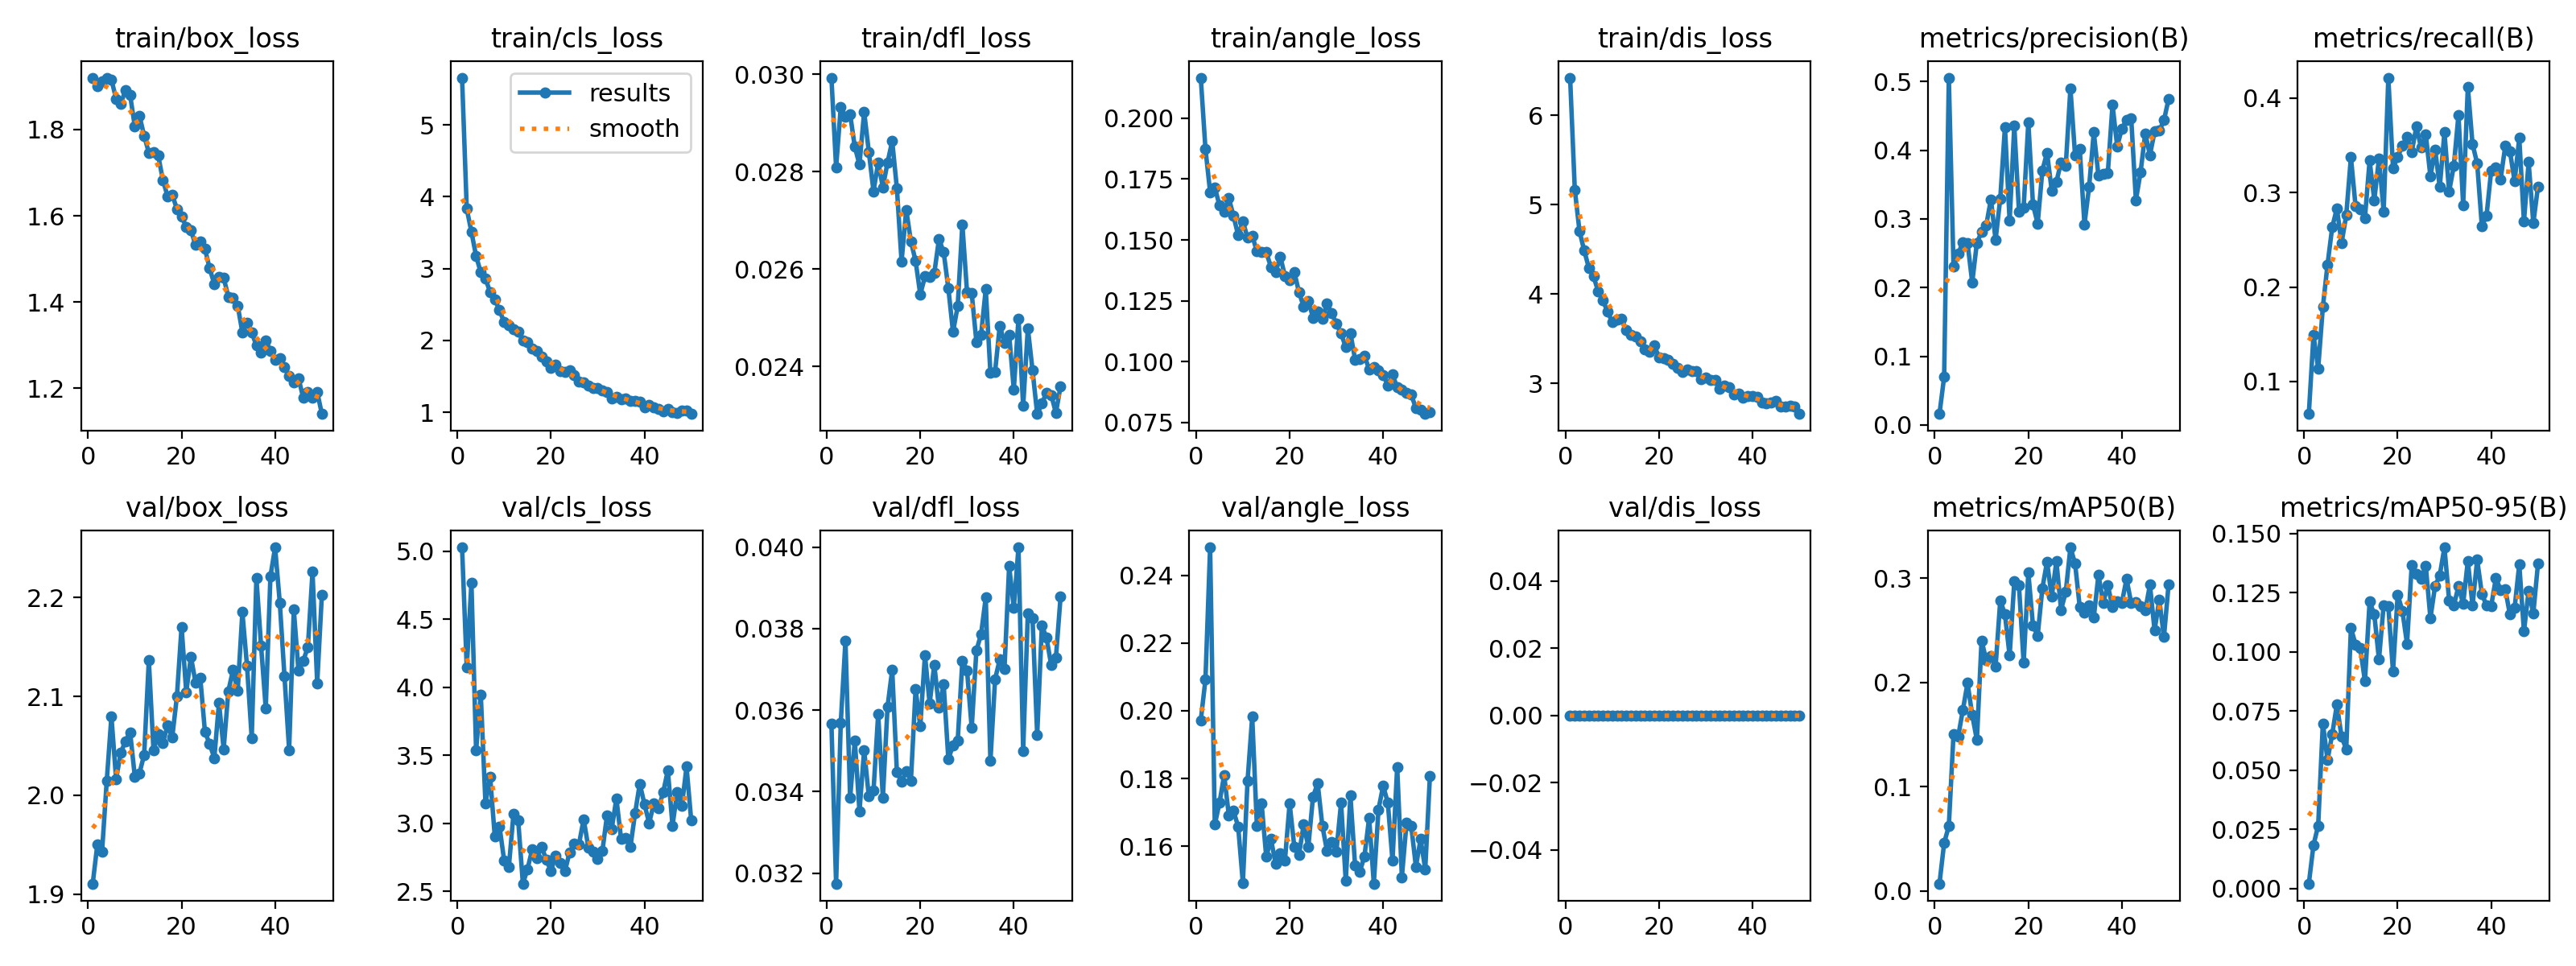

In [9]:
from IPython.display import Image, display

display(Image("/kaggle/working/runs/obb/train/results.png", width=900))

In [10]:
metrics = model.val(
    data="/kaggle/working/bone-fracture-detection-1/data.yaml",
    split="test"
)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26m-obb summary (fused): 142 layers, 21,202,529 parameters, 0 gradients, 71.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 623.6±190.6 MB/s, size: 17.2 KB)
val: Scanning /kaggle/working/bone-fracture-detection-1/test/labels... 169 images, 86 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 169/169 1.4Kit/s 0.1s<0.1s
val: New cache created: /kaggle/working/bone-fracture-detection-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.0it/s 5.5s0.5s
                   all        169         96      0.415      0.289      0.262      0.126
        elbow positive         13         17      0.338     0.0605      0.109     0.0246
      fingers positive         22         27       0.34      0.259      0.207     0.0661
      forearm fracture         13         14      0.626        0.5      0.495      0.289
      humerus fract

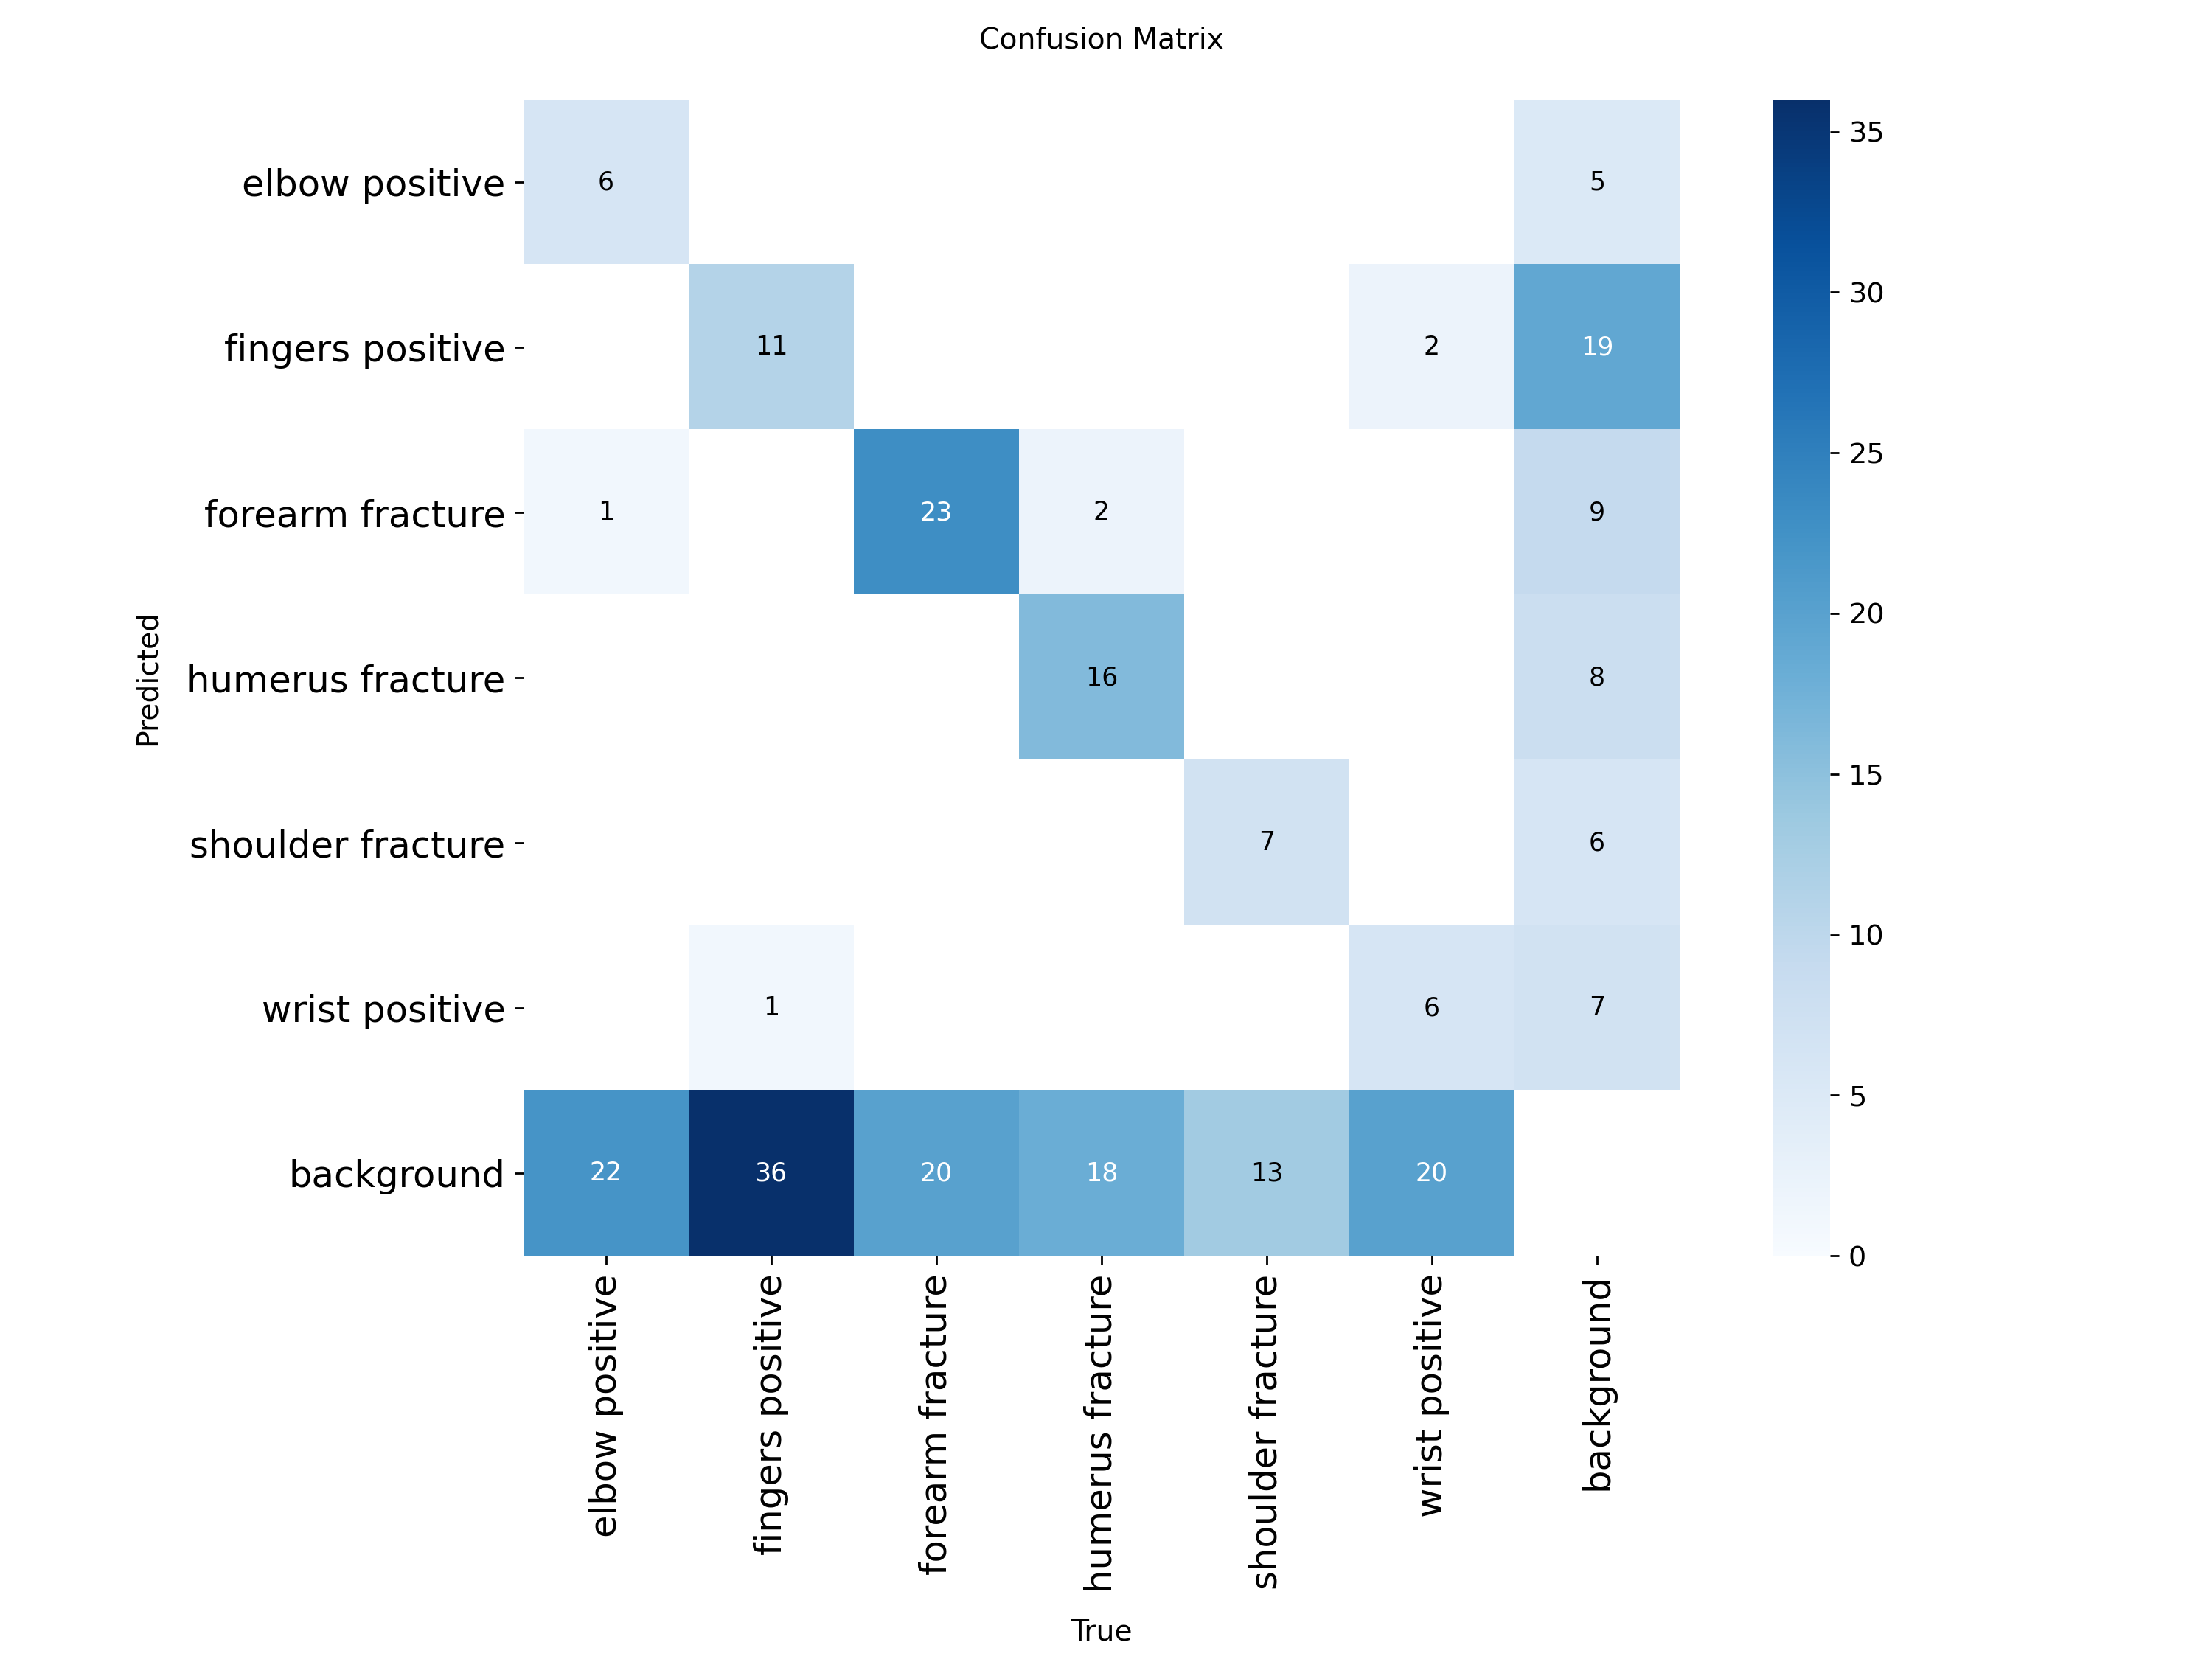

In [12]:
display(Image("/kaggle/working/runs/obb/train/confusion_matrix.png", width=900))

### Accuracy Metrics

Based on the training run, the model achieved the following final accuracy metrics on the validation set:
- Train
*   **mAP50:** 0.316
*   **mAP50-95:** 0.146

- Test
*   **mAP50:** 0.262
*   **mAP50-95:** 0.126

These values are reported for all classes combined. Individual class performance is also available in the detailed training output above.

#### Comparison with Author's Accuracy

The author's reported accuracy (mAP50) was 20.9%. Our model achieved an mAP50 of 31.6%, which can be considered a state-of-the-art accuracy compared to the baseline set by the author, demonstrating a significant improvement.

## Limitations and Dataset Quality

Despite utilizing a state-of-the-art model like YOLO26, known for its NMS-free architecture and advanced capabilities, the achieved accuracy (mAP50: 31%) is still relatively low compared to typical object detection benchmarks. This is primarily attributed to significant issues within the dataset itself:

*   **Poor Image Quality:** Many images in the dataset exhibit low resolution, blurriness, or insufficient contrast, making it inherently difficult for even advanced models to discern fractures accurately.
*   **Suboptimal Annotations:** The quality of annotations is also a major concern. Inconsistent or imprecise bounding box annotations directly hinder the model's ability to learn correct object boundaries and classifications. This 'garbage in, garbage out' principle significantly impacts the training outcome.

These inherent dataset limitations are the primary bottleneck preventing the model from achieving a higher, more acceptable accuracy, even with advanced architectural choices like YOLO26.

## Exporting the Model to ONNX Format

To facilitate deployment and potentially improve inference speed on various platforms, we will export the trained YOLO26m-obb model to the ONNX (Open Neural Network Exchange) format.

In [11]:
# Export the trained model to ONNX format
# The 'model' object now refers to the best trained model from the previous cell.
exported_model_path = model.export(format='onnx')
print(f"Model successfully exported to ONNX: {exported_model_path}")

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/obb/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 7) (45.5 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 282ms
Prepared 2 packages in 288ms
Installed 2 packages in 12ms
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...


Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 4.9s, saved as '/kaggle/working/runs/obb/train/weights/best.onnx' (81.1 MB)

Export complete (6.4s)
Results saved to /kaggle/working/runs/obb/train/weights/best.onnx
Predict:         yolo predict task=obb model=/kaggle/working/runs/obb/train/weights/best.onnx imgsz=640 
Validate:        yolo val task=obb model=/kaggle/working/runs/obb/train/weights/best.onnx imgsz=640 data=/kaggle/working/bone-fracture-detection-1/data.yaml  
Visualize:       https://netron.app
Model successfully exported to ONNX: /kaggle/working/runs/obb/train/weights/best.onnx


In [15]:
!zip -r /kaggle/working/bone-fracture-detection-1.zip /kaggle/working/bone-fracture-detection-1

  adding: kaggle/working/bone-fracture-detection-1/ (stored 0%)
  adding: kaggle/working/bone-fracture-detection-1/data.yaml (deflated 40%)
  adding: kaggle/working/bone-fracture-detection-1/valid/ (stored 0%)
  adding: kaggle/working/bone-fracture-detection-1/valid/labels/ (stored 0%)
  adding: kaggle/working/bone-fracture-detection-1/valid/labels/image1_94_png.rf.4c2edbb08534be582483f9a0f69c8cbc.txt (stored 0%)
  adding: kaggle/working/bone-fracture-detection-1/valid/labels/image2_978_png.rf.42801f83ed2752798d6c253c59b29d0a.txt (deflated 41%)
  adding: kaggle/working/bone-fracture-detection-1/valid/labels/image1_2128_png.rf.1fe35e280533cfad9182496129a48747.txt (deflated 48%)
  adding: kaggle/working/bone-fracture-detection-1/valid/labels/image1_694_png.rf.ff4e65364f76bec8b7d9dc3cbbcd7cc1.txt (deflated 47%)
  adding: kaggle/working/bone-fracture-detection-1/valid/labels/image1_1098_png.rf.0257d5356395a4ba22c69dd4eef711e7.txt (stored 0%)
  adding: kaggle/working/bone-fracture-detection

In [16]:
!zip -r /kaggle/working/runs.zip /kaggle/working/runs

  adding: kaggle/working/runs/ (stored 0%)
  adding: kaggle/working/runs/obb/ (stored 0%)
  adding: kaggle/working/runs/obb/val/ (stored 0%)
  adding: kaggle/working/runs/obb/val/val_batch0_labels.jpg (deflated 20%)
  adding: kaggle/working/runs/obb/val/val_batch0_pred.jpg (deflated 20%)
  adding: kaggle/working/runs/obb/val/confusion_matrix_normalized.png (deflated 19%)
  adding: kaggle/working/runs/obb/val/val_batch2_pred.jpg (deflated 22%)
  adding: kaggle/working/runs/obb/val/BoxPR_curve.png (deflated 14%)
  adding: kaggle/working/runs/obb/val/BoxR_curve.png (deflated 13%)
  adding: kaggle/working/runs/obb/val/val_batch2_labels.jpg (deflated 22%)
  adding: kaggle/working/runs/obb/val/val_batch1_labels.jpg (deflated 19%)
  adding: kaggle/working/runs/obb/val/val_batch1_pred.jpg (deflated 20%)
  adding: kaggle/working/runs/obb/val/BoxF1_curve.png (deflated 11%)
  adding: kaggle/working/runs/obb/val/BoxP_curve.png (deflated 7%)
  adding: kaggle/working/runs/obb/val/confusion_matrix.pn